In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
dataset = pd.read_csv(r"/home/satyajit-sahoo/Downloads/bank-loan.csv")
dataset.head(4)

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,area,married,Gender
0,41,3,17,12,NaN,9.3,11.359392,5.008608,1.0,Urban,No,Female
1,27,1,10,6,31.0,17.3,1.362202,4.000798,0.0,Rural,Yes,Male
2,40,1,15,14,55.0,5.5,0.856075,2.168925,0.0,Urban,Yes,Female
3,41,1,15,14,120.0,2.9,2.658720,0.821280,0.0,NaN,Yes,Male


In [56]:
dataset.shape

(850, 12)

In [57]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    849 non-null    float64
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
 9   area      3 non-null      object 
 10  married   7 non-null      object 
 11  Gender    9 non-null      object 
dtypes: float64(5), int64(4), object(3)
memory usage: 79.8+ KB


In [58]:
dataset.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,849.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.522968,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.308914,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.000000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [59]:
dataset["income"] = dataset["income"].fillna(dataset["income"].mode()[0])

In [60]:
dataset.isnull().sum()

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
area        847
married     843
Gender      841
dtype: int64

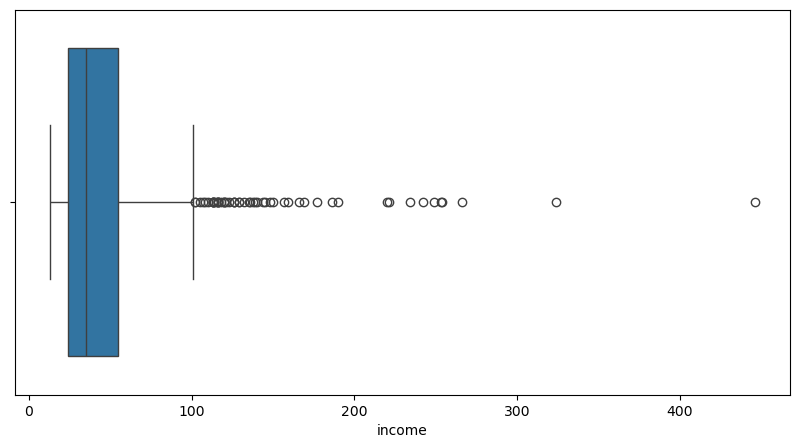

In [61]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="income", data=dataset)
plt.show()

In [62]:
# using distribution plot

In [63]:
# sns.histplot(dataset["income"], kde=True)
# plt.show()

In [64]:
# Outlier removal using IQR(Inter Quantile Range)

In [65]:
# IQR = Q3(75% of data) - Q1(25% of data)
# min = Q1 - (1.5 * IQR)
# max = Q3 + (1.5 * IQR)

In [66]:
dataset.head(4)

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,area,married,Gender
0,41,3,17,12,21.0,9.3,11.359392,5.008608,1.0,Urban,No,Female
1,27,1,10,6,31.0,17.3,1.362202,4.000798,0.0,Rural,Yes,Male
2,40,1,15,14,55.0,5.5,0.856075,2.168925,0.0,Urban,Yes,Female
3,41,1,15,14,120.0,2.9,2.658720,0.821280,0.0,NaN,Yes,Male


In [67]:
dataset.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.492941,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.296353,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.000000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [68]:
dataset.shape

(850, 12)

In [69]:
Q1 = dataset["income"].quantile(0.25)
Q3 = dataset["income"].quantile(0.75)

In [70]:
IQR = Q3 - Q1

In [71]:
min_range = Q1 - (1.5 * IQR)
max_range = Q3 + (1.5 * IQR)
min_range, max_range

(-22.5, 101.5)

In [72]:
# remove outlier data
new_dataset = dataset[dataset["income"] <= max_range]

In [73]:
new_dataset.shape

(796, 12)

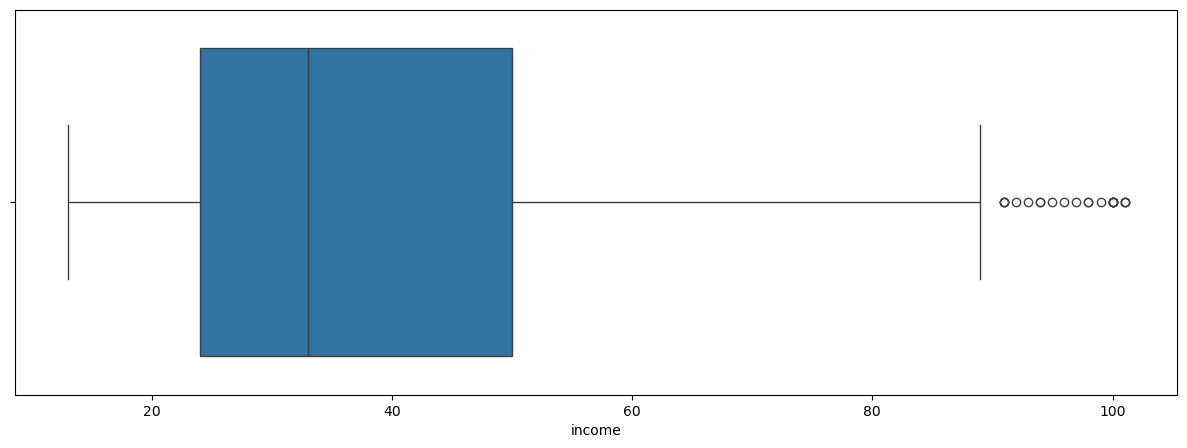

In [74]:
plt.figure(figsize=(15, 5))
sns.boxplot(x="income", data=new_dataset)
plt.show()

In [75]:
# Outlier removal using Z Score
# z = x - μ(Mean) / σ(Standard Division)

In [76]:
dataset.isnull().sum()

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
area        847
married     843
Gender      841
dtype: int64

In [77]:
dataset.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.492941,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.296353,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.000000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


<Axes: xlabel='income'>

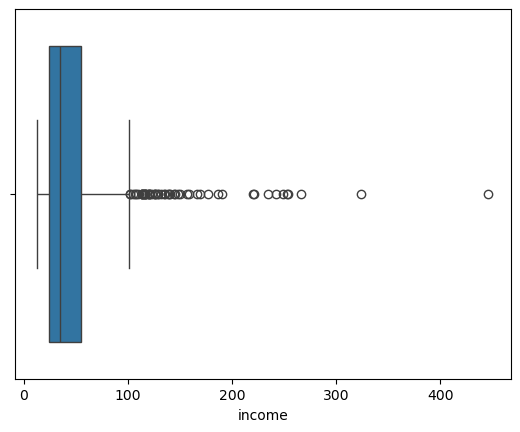

In [78]:
sns.boxplot(x="income", data=dataset)

<Axes: xlabel='income', ylabel='Count'>

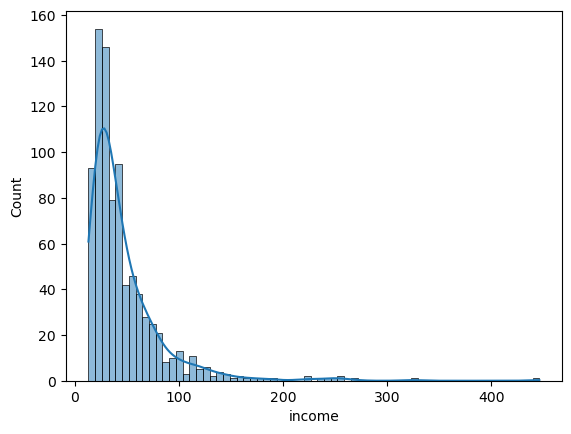

In [79]:
sns.histplot(dataset["income"], kde=True)

In [80]:
# 1st way
# minRange = μ(Mean) - 3*σ(Standard Division)
# maxRange = μ(Mean) + 3*σ(Standard Division)

In [81]:
min_range = dataset["income"].mean() - 3*dataset["income"].std()
max_range = dataset["income"].mean() + 3*dataset["income"].std()

In [82]:
min_range, max_range

(-68.39611843087403, 161.38200078381522)

In [83]:
# outlier data
new_data = dataset[dataset["income"]<=max_range]
new_data.shape

(835, 12)

<Axes: xlabel='income'>

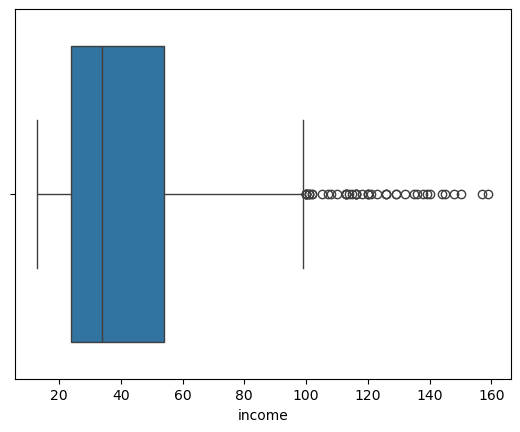

In [84]:
sns.boxplot(x="income", data=new_data)

In [85]:
# 2nd way -  using z-score

In [86]:
z_score = (dataset["income"] - dataset["income"].mean())/(dataset["income"].std())

In [87]:
z_score

0     -0.665675
1     -0.404554
2      0.222138
3      1.919427
4     -0.482890
         ...   
845   -0.378442
846    1.814979
847   -0.221769
848   -0.587339
849   -0.143432
Name: income, Length: 850, dtype: float64

In [88]:
z_score>3

0      False
1      False
2      False
3      False
4      False
       ...  
845    False
846    False
847    False
848    False
849    False
Name: income, Length: 850, dtype: bool

In [89]:
dataset["z_score"] = z_score

In [90]:
dataset

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,area,married,Gender,z_score
0,41,3,17,12,21.0,9.3,11.359392,5.008608,1.0,Urban,No,Female,-0.665675
1,27,1,10,6,31.0,17.3,1.362202,4.000798,0.0,Rural,Yes,Male,-0.404554
2,40,1,15,14,55.0,5.5,0.856075,2.168925,0.0,Urban,Yes,Female,0.222138
3,41,1,15,14,120.0,2.9,2.658720,0.821280,0.0,NaN,Yes,Male,1.919427
4,24,2,2,0,28.0,17.3,1.787436,3.056564,1.0,NaN,Yes,Male,-0.482890
...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,34,1,12,15,32.0,2.7,0.239328,0.624672,NaN,NaN,NaN,NaN,-0.378442
846,32,2,12,11,116.0,5.7,4.026708,2.585292,NaN,NaN,NaN,NaN,1.814979
847,48,1,13,11,38.0,10.8,0.722304,3.381696,NaN,NaN,NaN,NaN,-0.221769
848,35,2,1,11,24.0,7.8,0.417456,1.454544,NaN,NaN,NaN,NaN,-0.587339


In [91]:
dataset[dataset["z_score"]<3]

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,area,married,Gender,z_score
0,41,3,17,12,21.0,9.3,11.359392,5.008608,1.0,Urban,No,Female,-0.665675
1,27,1,10,6,31.0,17.3,1.362202,4.000798,0.0,Rural,Yes,Male,-0.404554
2,40,1,15,14,55.0,5.5,0.856075,2.168925,0.0,Urban,Yes,Female,0.222138
3,41,1,15,14,120.0,2.9,2.658720,0.821280,0.0,NaN,Yes,Male,1.919427
4,24,2,2,0,28.0,17.3,1.787436,3.056564,1.0,NaN,Yes,Male,-0.482890
...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,34,1,12,15,32.0,2.7,0.239328,0.624672,NaN,NaN,NaN,NaN,-0.378442
846,32,2,12,11,116.0,5.7,4.026708,2.585292,NaN,NaN,NaN,NaN,1.814979
847,48,1,13,11,38.0,10.8,0.722304,3.381696,NaN,NaN,NaN,NaN,-0.221769
848,35,2,1,11,24.0,7.8,0.417456,1.454544,NaN,NaN,NaN,NaN,-0.587339
